Задание. Найти выходж из лабиринта при помощи алгоритмов DFS и BFS. Картинки в папке task1.

Cравнить время выполнения и пути при помощи DFS и BFS

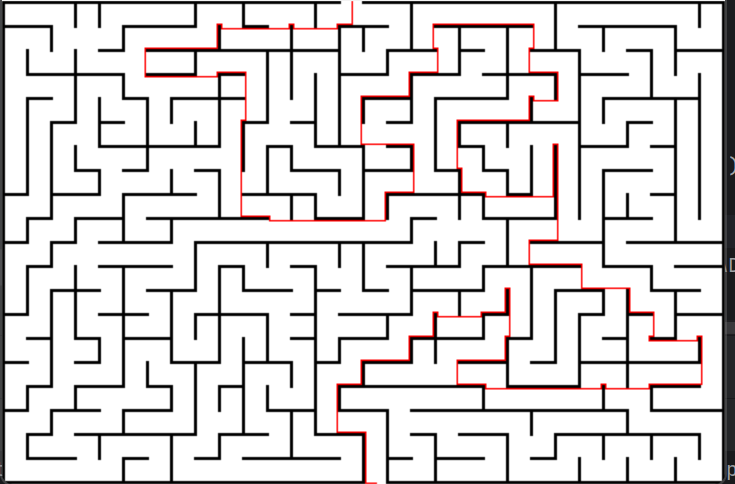

In [41]:
import numpy as np
import cv2
from PIL import Image
from pathlib import Path
import time

from collections import deque

import matplotlib.pyplot as plt
%matplotlib inline

In [42]:
def plot_maze_path(img, path):
    img = img.copy()
    if img.ndim != 3:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    
    img = img.copy()
    for point in path:
        cv2.circle(img , point, 1, (255, 0, 0), -1)

    for i in range(len(path ) - 1):
        cv2.line(img, path[i], path[i+1], (255, 0, 0), 1)
        
    return img           

In [43]:
def plot_one_image(image: np.ndarray):
    """
    Отобразить изображение с помощью matplotlib.
    Вспомогательная функция.
    
    :param image: изображение для отображения
    :return: None
    """
    plt.figure(figsize=(8, 7))
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(image)

    plt.axis('off')
    plt.show()

In [44]:
def get_start_end_point(grid):
    """
    Найти координаты старта и выхода (x, y).

    :param grid: матрица лабиринта для анализа
    """
    # Поиск будем вести на границах изображения лабиринта, представив его
    # как двумерный массив, где:
    # - 0 (чёрный) - стена
    # - 255 (белый) - проход

    # Получаем размеры изображения в пикселях
    h, w = grid.shape

    # Список для хранения найденных точек входа и выхода
    points = []

    # Сканируем верхнюю и нижнюю границы (двигаемся по оси X слева направо)
    for x in range(w):
        # Если пиксель на самом верху светлый, считаем его проходом
        if grid[0, x] > 128:
            points.append((x, 0))
            # break
        
        # Если пиксель в самом низу светлый, тоже считаем его проходом
        if grid[h-1, x] > 128:
            points.append((x, h-1))
            # break
    
    # Сканируем левую и правую границы (двигаемся по оси Y сверху вниз)
    for y in range(h):
        # Проверяем левую границу (x = 0)
        if grid[y, 0] > 128:
            points.append((0, y))
            # break
        
        # Проверяем правую границу (x = w-1)
        if grid[y, w-1] > 128:
            points.append((w-1, y))
            # break

    # Если мы нашли как минимум 2 точки (вход и выход)
    if len(set(points)) >= 2:
        start_point = points[0]
        end_point = points[-1]
        return start_point, end_point

    # Если лабиринт закрыт со всех сторон, возвращаем пару None
    return None, None

In [45]:
def _search_path(grid, start, end, method='bfs'):
    """
    Логика обхода графа.
    """
    h, w = grid.shape

    # Выбор структуры данных в зависимости от алгоритма:
    #
    # Для BFS требуется очередь, представим её в виде дека, для эффективности
    # при удалении первого элемента
    # Для DFS требуется стек, который можно представить обычным списком
    structure = deque([start]) if method == 'bfs' else [start]

    # Множество, хранящее координаты уже пройденных точек
    visited = {start}

    # Словарь, хранящий историю шагов (для последующего восстановления пути)
    parent = {start: None}

    # Возможные шаги
    directions = [
        (0, -1),    # влево
        (1, 0),     # вправо
        (0, 1),     # вниз
        (-1, 0),    # вверх
    ]

    # Пока в структуре есть точки для проверки
    while structure:
        # Получаем следующую точку

        # При BFS берём самую старую, идя равномерно во все сторорны
        # При DFS берем самую новую, идя вглубь до упора
        current = structure.popleft() if method == 'bfs' else structure.pop()

        # Если достигли выхода - останавливаем поиск
        if current == end: break

        # Распаковываем текущие координаты
        x, y = current

        # Пробуем совершить шаг в каждую из 4 сторон
        for dx, dy in directions:
            nx, ny = x + dx, y + dy

            # Проверка 1: Совершён ли выход за границы изображения?
            if 0 <= nx < w and 0 <= ny < h:
                # Проверка 2: Является ли пиксель светлым (проходом)?
                # Проверка 3: Является ли пиксель посещённым?
                if grid[ny, nx] > 128 and (nx, ny) not in visited:
                    # Помечаем клетку как посещённую
                    visited.add((nx, ny))
                    # Запоминаем, что в (nx, ny) мы пришли из текущей клетки
                    parent[(nx, ny)] = current
                    # Добавляем новую клетку в структуру данных для
                    # дальнейшей проверки
                    structure.append((nx, ny))

    # Восстанавливаем путь от конца к началу
    path = []
    curr = end

    # Если финищ есть в словаре parent, значит мы смогли дойти до него
    if curr in parent:
        while curr is not None:
            # Добавляем клетку в итоговый маршрут
            path.append(curr)
            # Смотрим, откуда в неё пришли, и делаем шаг назад
            curr = parent[curr]

        # Разворачиваем путь, чтобы он шёл от старта к финишу
        path.reverse()
    
    return path

In [46]:
def find_way_from_maze(image: np.ndarray, method='bfs'):
    """
    Найти путь через лабиринт.

    :param image: изображение лабиринта
    :return: координаты пути из лабиринта в виде (x, y), где x и y - это массивы координат
    """
    start, end = get_start_end_point(image)

    # Валидация лабиринта
    if start is None or end is None:
        print("Не удалось найти вход или выход на границаз изображения.")
        return []

    # Используем функцию поиска для получения пути
    path = _search_path(image, start, end, method)

    return path

['task_1/20 by 22 orthogonal maze.png', 'task_1/20 by 20 orthogonal maze.png', 'task_1/30 by 30 orthogonal maze.png', 'task_1/30 by 20 orthogonal maze.png', 'task_1/25 by 22 orthogonal maze.png']
Время поиска с помощью DFS:  0.06763482093811035


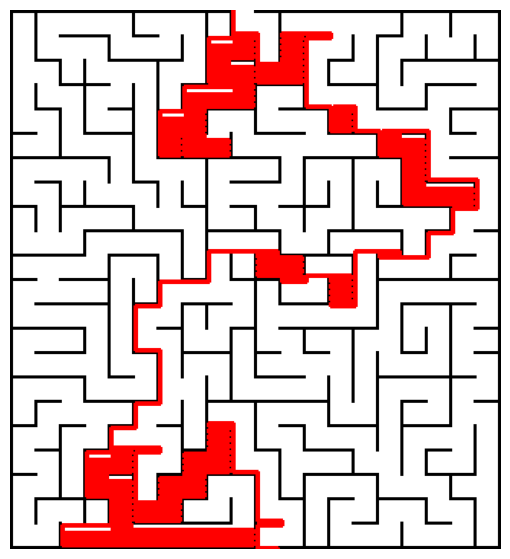

[(146, 0), (146, 1), (146, 2), (146, 3), (146, 4), (146, 5), (146, 6), (146, 7), (146, 8), (146, 9), (146, 10), (146, 11), (146, 12), (146, 13), (146, 14), (146, 15), (146, 16), (146, 17), (146, 18), (145, 18), (144, 18), (143, 18), (142, 18), (141, 18), (140, 18), (139, 18), (138, 18), (137, 18), (136, 18), (135, 18), (134, 18), (133, 18), (132, 18), (131, 18), (130, 18), (130, 19), (130, 20), (130, 21), (130, 22), (130, 23), (130, 24), (130, 25), (130, 26), (130, 27), (130, 28), (130, 29), (130, 30), (130, 31), (130, 32), (130, 33), (130, 34), (130, 35), (130, 36), (130, 37), (130, 38), (130, 39), (130, 40), (130, 41), (130, 42), (130, 43), (130, 44), (130, 45), (130, 46), (130, 47), (131, 47), (132, 47), (133, 47), (134, 47), (135, 47), (136, 47), (137, 47), (138, 47), (139, 47), (140, 47), (141, 47), (142, 47), (143, 47), (144, 47), (145, 47), (146, 47), (146, 48), (146, 49), (146, 50), (145, 50), (144, 50), (143, 50), (142, 50), (141, 50), (140, 50), (139, 50), (138, 50), (137, 50

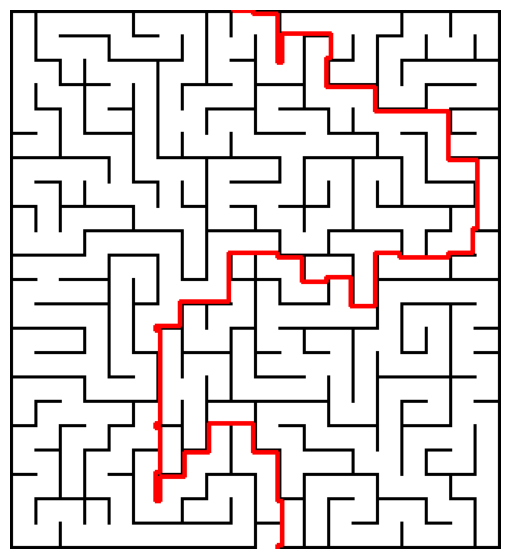

[(146, 0), (147, 0), (148, 0), (149, 0), (150, 0), (151, 0), (152, 0), (153, 0), (154, 0), (155, 0), (156, 0), (157, 0), (158, 0), (159, 0), (159, 1), (159, 2), (160, 2), (161, 2), (162, 2), (163, 2), (164, 2), (165, 2), (166, 2), (167, 2), (168, 2), (169, 2), (170, 2), (171, 2), (172, 2), (173, 2), (174, 2), (175, 2), (175, 3), (175, 4), (175, 5), (175, 6), (175, 7), (175, 8), (175, 9), (175, 10), (175, 11), (175, 12), (175, 13), (175, 14), (175, 15), (175, 16), (175, 17), (175, 18), (175, 19), (175, 20), (175, 21), (175, 22), (175, 23), (175, 24), (175, 25), (175, 26), (175, 27), (175, 28), (175, 29), (175, 30), (175, 31), (175, 32), (175, 33), (175, 34), (176, 34), (177, 34), (178, 34), (178, 33), (178, 32), (178, 31), (178, 30), (178, 29), (178, 28), (178, 27), (178, 26), (178, 25), (178, 24), (178, 23), (178, 22), (178, 21), (178, 20), (178, 19), (178, 18), (178, 17), (178, 16), (178, 15), (179, 15), (180, 15), (181, 15), (182, 15), (183, 15), (184, 15), (185, 15), (186, 15), (187

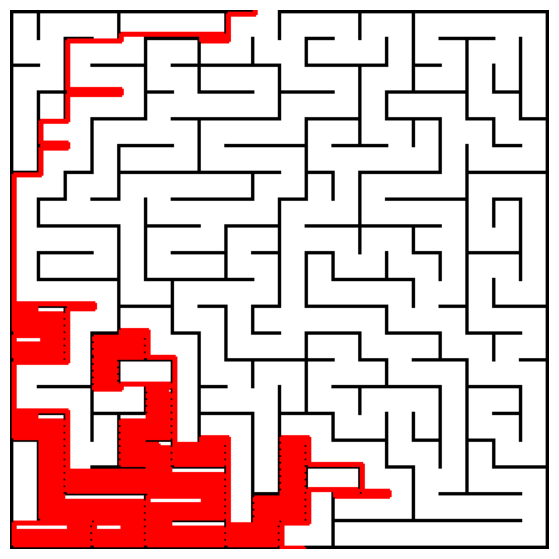

[(146, 0), (146, 1), (146, 2), (145, 2), (144, 2), (143, 2), (142, 2), (141, 2), (140, 2), (139, 2), (138, 2), (137, 2), (136, 2), (135, 2), (134, 2), (133, 2), (132, 2), (131, 2), (130, 2), (130, 3), (130, 4), (130, 5), (130, 6), (130, 7), (130, 8), (130, 9), (130, 10), (130, 11), (130, 12), (130, 13), (130, 14), (130, 15), (130, 16), (130, 17), (130, 18), (129, 18), (128, 18), (127, 18), (126, 18), (125, 18), (124, 18), (123, 18), (122, 18), (121, 18), (120, 18), (119, 18), (118, 18), (117, 18), (116, 18), (115, 18), (114, 18), (114, 17), (114, 16), (115, 16), (116, 16), (117, 16), (118, 16), (119, 16), (120, 16), (121, 16), (122, 16), (123, 16), (124, 16), (125, 16), (126, 16), (127, 16), (127, 15), (127, 14), (126, 14), (125, 14), (124, 14), (123, 14), (122, 14), (121, 14), (120, 14), (119, 14), (118, 14), (117, 14), (116, 14), (115, 14), (114, 14), (113, 14), (112, 14), (111, 14), (110, 14), (109, 14), (108, 14), (107, 14), (106, 14), (105, 14), (104, 14), (103, 14), (102, 14), (1

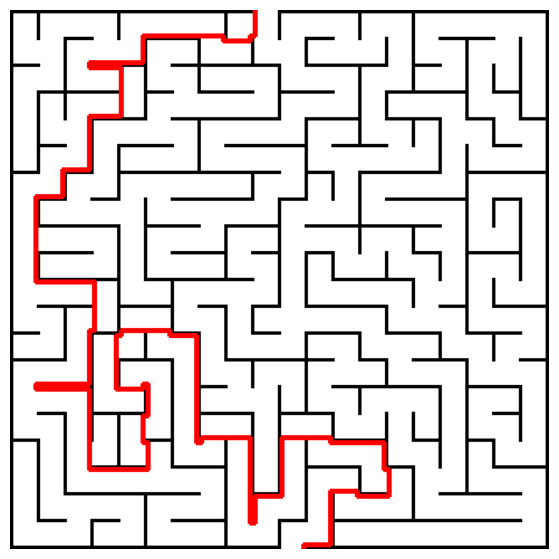

[(146, 0), (146, 1), (146, 2), (146, 3), (146, 4), (146, 5), (146, 6), (146, 7), (146, 8), (146, 9), (146, 10), (146, 11), (146, 12), (146, 13), (146, 14), (146, 15), (145, 15), (144, 15), (143, 15), (143, 16), (143, 17), (143, 18), (142, 18), (141, 18), (140, 18), (139, 18), (138, 18), (137, 18), (136, 18), (135, 18), (134, 18), (133, 18), (132, 18), (131, 18), (130, 18), (129, 18), (128, 18), (127, 18), (127, 17), (127, 16), (127, 15), (126, 15), (125, 15), (124, 15), (123, 15), (122, 15), (121, 15), (120, 15), (119, 15), (118, 15), (117, 15), (116, 15), (115, 15), (114, 15), (113, 15), (112, 15), (111, 15), (110, 15), (109, 15), (108, 15), (107, 15), (106, 15), (105, 15), (104, 15), (103, 15), (102, 15), (101, 15), (100, 15), (99, 15), (98, 15), (97, 15), (96, 15), (95, 15), (94, 15), (93, 15), (92, 15), (91, 15), (90, 15), (89, 15), (88, 15), (87, 15), (86, 15), (85, 15), (84, 15), (83, 15), (82, 15), (81, 15), (80, 15), (79, 15), (79, 16), (79, 17), (79, 18), (79, 19), (79, 20), (

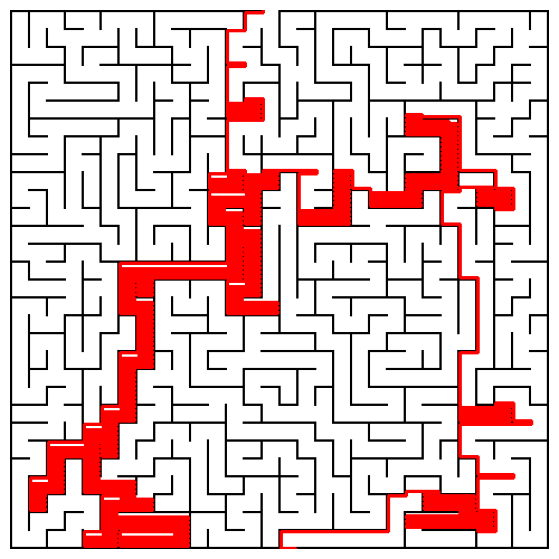

[(226, 0), (226, 1), (226, 2), (225, 2), (224, 2), (223, 2), (222, 2), (221, 2), (220, 2), (219, 2), (218, 2), (217, 2), (216, 2), (215, 2), (214, 2), (213, 2), (212, 2), (211, 2), (210, 2), (210, 3), (210, 4), (210, 5), (210, 6), (210, 7), (210, 8), (210, 9), (210, 10), (210, 11), (210, 12), (210, 13), (210, 14), (210, 15), (210, 16), (210, 17), (210, 18), (209, 18), (208, 18), (207, 18), (206, 18), (205, 18), (204, 18), (203, 18), (202, 18), (201, 18), (200, 18), (199, 18), (198, 18), (197, 18), (196, 18), (195, 18), (194, 18), (194, 19), (194, 20), (194, 21), (194, 22), (194, 23), (194, 24), (194, 25), (194, 26), (194, 27), (194, 28), (194, 29), (194, 30), (194, 31), (194, 32), (194, 33), (194, 34), (194, 35), (194, 36), (194, 37), (194, 38), (194, 39), (194, 40), (194, 41), (194, 42), (194, 43), (194, 44), (194, 45), (194, 46), (194, 47), (195, 47), (196, 47), (197, 47), (198, 47), (199, 47), (200, 47), (201, 47), (202, 47), (203, 47), (204, 47), (205, 47), (206, 47), (207, 47), (2

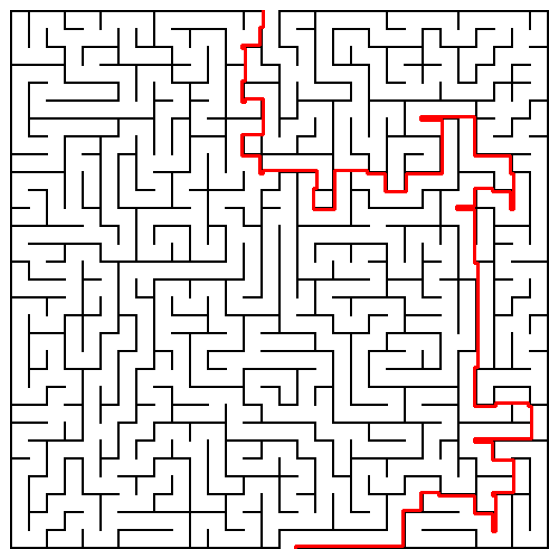

[(226, 0), (226, 1), (226, 2), (226, 3), (226, 4), (226, 5), (226, 6), (226, 7), (226, 8), (226, 9), (226, 10), (226, 11), (226, 12), (226, 13), (226, 14), (226, 15), (225, 15), (224, 15), (223, 15), (223, 16), (223, 17), (223, 18), (223, 19), (223, 20), (223, 21), (223, 22), (223, 23), (223, 24), (223, 25), (223, 26), (223, 27), (223, 28), (223, 29), (223, 30), (223, 31), (222, 31), (221, 31), (220, 31), (219, 31), (218, 31), (217, 31), (216, 31), (215, 31), (214, 31), (213, 31), (212, 31), (211, 31), (210, 31), (209, 31), (208, 31), (207, 31), (207, 32), (207, 33), (207, 34), (208, 34), (209, 34), (210, 34), (210, 35), (210, 36), (210, 37), (210, 38), (210, 39), (210, 40), (210, 41), (210, 42), (210, 43), (210, 44), (210, 45), (210, 46), (210, 47), (210, 48), (210, 49), (210, 50), (210, 51), (210, 52), (210, 53), (210, 54), (210, 55), (210, 56), (210, 57), (210, 58), (210, 59), (210, 60), (210, 61), (210, 62), (210, 63), (209, 63), (208, 63), (207, 63), (207, 64), (207, 65), (207, 66

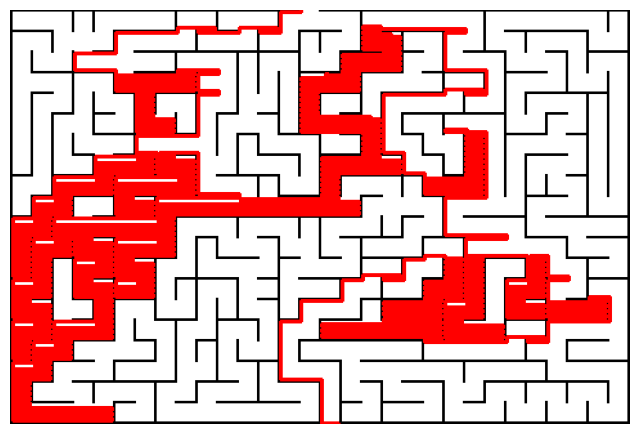

[(226, 0), (226, 1), (226, 2), (225, 2), (224, 2), (223, 2), (222, 2), (221, 2), (220, 2), (219, 2), (218, 2), (217, 2), (216, 2), (215, 2), (214, 2), (213, 2), (212, 2), (211, 2), (210, 2), (210, 3), (210, 4), (210, 5), (210, 6), (210, 7), (210, 8), (210, 9), (210, 10), (210, 11), (210, 12), (210, 13), (210, 14), (210, 15), (210, 16), (210, 17), (210, 18), (209, 18), (208, 18), (207, 18), (206, 18), (205, 18), (204, 18), (203, 18), (202, 18), (201, 18), (200, 18), (199, 18), (198, 18), (197, 18), (196, 18), (195, 18), (194, 18), (194, 17), (194, 16), (195, 16), (196, 16), (197, 16), (198, 16), (199, 16), (200, 16), (201, 16), (202, 16), (203, 16), (204, 16), (205, 16), (206, 16), (207, 16), (207, 15), (207, 14), (206, 14), (205, 14), (204, 14), (203, 14), (202, 14), (201, 14), (200, 14), (199, 14), (198, 14), (197, 14), (196, 14), (195, 14), (194, 14), (193, 14), (192, 14), (191, 14), (190, 14), (189, 14), (188, 14), (187, 14), (186, 14), (185, 14), (184, 14), (183, 14), (182, 14), (1

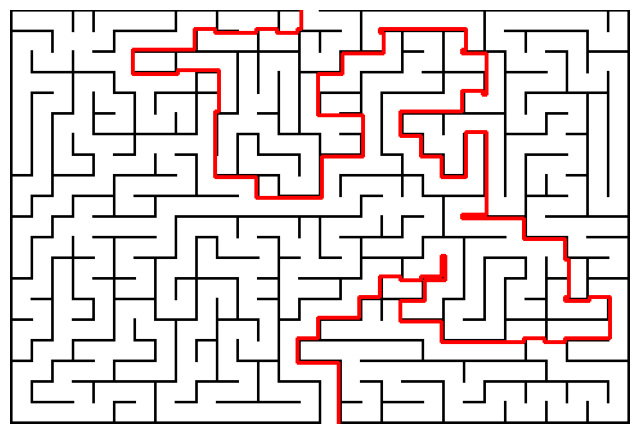

[(226, 0), (226, 1), (226, 2), (226, 3), (226, 4), (226, 5), (226, 6), (226, 7), (226, 8), (226, 9), (226, 10), (226, 11), (226, 12), (226, 13), (226, 14), (226, 15), (225, 15), (224, 15), (223, 15), (223, 16), (223, 17), (223, 18), (222, 18), (221, 18), (220, 18), (219, 18), (218, 18), (217, 18), (216, 18), (215, 18), (214, 18), (213, 18), (212, 18), (211, 18), (210, 18), (209, 18), (208, 18), (207, 18), (207, 17), (207, 16), (207, 15), (206, 15), (205, 15), (204, 15), (203, 15), (202, 15), (201, 15), (200, 15), (199, 15), (198, 15), (197, 15), (196, 15), (195, 15), (194, 15), (193, 15), (192, 15), (191, 15), (191, 16), (191, 17), (191, 18), (190, 18), (189, 18), (188, 18), (187, 18), (186, 18), (185, 18), (184, 18), (183, 18), (182, 18), (181, 18), (180, 18), (179, 18), (178, 18), (177, 18), (176, 18), (175, 18), (174, 18), (173, 18), (172, 18), (171, 18), (170, 18), (169, 18), (168, 18), (167, 18), (166, 18), (165, 18), (164, 18), (163, 18), (162, 18), (161, 18), (160, 18), (159, 18

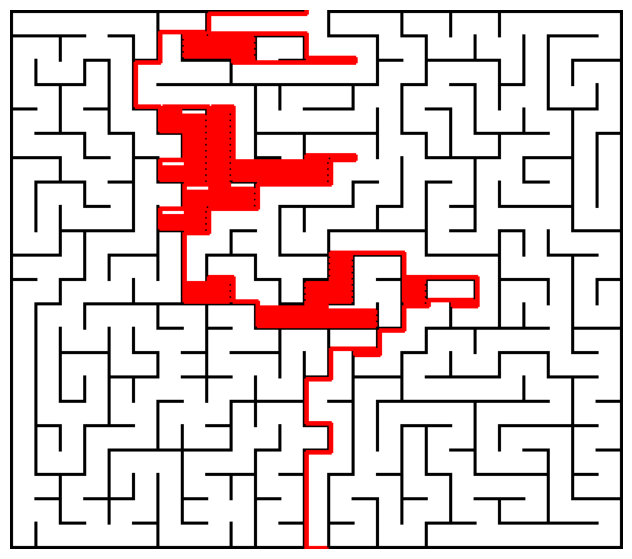

[(194, 0), (194, 1), (194, 2), (193, 2), (192, 2), (191, 2), (190, 2), (189, 2), (188, 2), (187, 2), (186, 2), (185, 2), (184, 2), (183, 2), (182, 2), (181, 2), (180, 2), (179, 2), (178, 2), (177, 2), (176, 2), (175, 2), (174, 2), (173, 2), (172, 2), (171, 2), (170, 2), (169, 2), (168, 2), (167, 2), (166, 2), (165, 2), (164, 2), (163, 2), (162, 2), (161, 2), (160, 2), (159, 2), (158, 2), (157, 2), (156, 2), (155, 2), (154, 2), (153, 2), (152, 2), (151, 2), (150, 2), (149, 2), (148, 2), (147, 2), (146, 2), (145, 2), (144, 2), (143, 2), (142, 2), (141, 2), (140, 2), (139, 2), (138, 2), (137, 2), (136, 2), (135, 2), (134, 2), (133, 2), (132, 2), (131, 2), (130, 2), (130, 3), (130, 4), (130, 5), (130, 6), (130, 7), (130, 8), (130, 9), (130, 10), (130, 11), (130, 12), (130, 13), (130, 14), (130, 15), (131, 15), (132, 15), (133, 15), (134, 15), (135, 15), (136, 15), (137, 15), (138, 15), (139, 15), (140, 15), (141, 15), (142, 15), (143, 15), (144, 15), (145, 15), (146, 15), (147, 15), (148, 

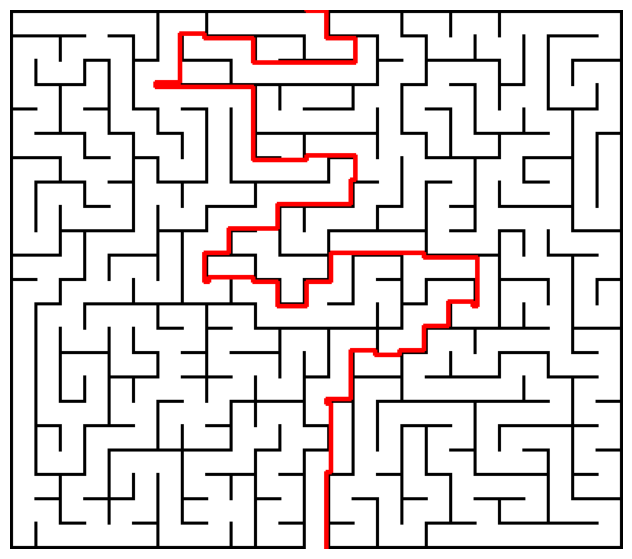

[(194, 0), (195, 0), (196, 0), (197, 0), (198, 0), (199, 0), (200, 0), (201, 0), (202, 0), (203, 0), (204, 0), (205, 0), (206, 0), (207, 0), (207, 1), (207, 2), (207, 3), (207, 4), (207, 5), (207, 6), (207, 7), (207, 8), (207, 9), (207, 10), (207, 11), (207, 12), (207, 13), (207, 14), (207, 15), (207, 16), (207, 17), (207, 18), (208, 18), (209, 18), (210, 18), (211, 18), (212, 18), (213, 18), (214, 18), (215, 18), (216, 18), (217, 18), (218, 18), (219, 18), (220, 18), (221, 18), (222, 18), (223, 18), (224, 18), (225, 18), (226, 18), (226, 19), (226, 20), (226, 21), (226, 22), (226, 23), (226, 24), (226, 25), (226, 26), (226, 27), (226, 28), (226, 29), (226, 30), (226, 31), (226, 32), (226, 33), (226, 34), (225, 34), (224, 34), (223, 34), (222, 34), (221, 34), (220, 34), (219, 34), (218, 34), (217, 34), (216, 34), (215, 34), (214, 34), (213, 34), (212, 34), (211, 34), (210, 34), (209, 34), (208, 34), (207, 34), (206, 34), (205, 34), (204, 34), (203, 34), (202, 34), (201, 34), (200, 34),

In [47]:
# Получаем все файлы с лабиринтами
images = [str(f) for f in Path('task_1').glob('*.png')]

i = -1
image = cv2.imread(images[i], cv2.IMREAD_GRAYSCALE)
test_image = cv2.imread(images[i])

print(images)

for img in images:
    image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)

    # Проверка алгоритма DFS: 
    start_time = time.time()
    path = find_way_from_maze(image, method='dfs')
    end_time = time.time()
    print('Время поиска с помощью DFS: ', end_time - start_time)

    new_image = plot_maze_path(image, path)
    plot_one_image(new_image)

    print(path)

    # Проверка алгоритма BFS:
    start_time = time.time()
    path = find_way_from_maze(image)
    end_time = time.time()

    print('Время поиска с помощью BFS: ', end_time - start_time)

    new_image = plot_maze_path(image, path)
    plot_one_image(new_image)

    print(path)